# E-Commerce Product Analytics: Conversion Funnel, A/B Testing & Unit Economics

## Project Objectives
This portfolio project focuses on extracting actionable product insights from the "Maven Fuzzy Factory" database using advanced SQL and Python. The core objectives are:
1. **Product Funnel Analysis:** Build a multi-step conversion funnel (from `/home` to `/billing`) to identify user drop-off points and optimize UX.
2. **A/B Testing:** Conduct statistical testing to compare experimental landing pages against the default homepage, identifying the optimal user entry point to maximize the final order conversion rate.
3. **Marketing Analytics & Traffic Optimization:** Analyze UTM parameters to evaluate campaign profitability (Revenue per Session), identify device-level purchasing behaviors for bid adjustments, and compare brand vs. non-brand traffic dynamics.
3. **Core Business Metrics:** Calculate and visualize key performance indicators, including Retention, ARPU (Average Revenue Per User), Churn Rate, Refund Rate.

### Environment Setup & Database Connection
Instead of exporting data manually, we use `SQLAlchemy` to establish a direct connection to our MySQL database. 

In [ ]:
import pandas as pd
import plotly.express as px
from sqlalchemy import create_engine

import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest

# Establish connection to MySQL
db_connection_str = 'mysql+pymysql://product_analyst:<YOUR_PASSWORD>@localhost:3306/maven_fuzzy_factory'
engine = create_engine(db_connection_str)

In [ ]:
files_to_load = [
    ('products', 'data/products.csv'),  
    ('website_sessions', 'data/website_sessions.csv'),
    ('website_pageviews', 'data/website_pageviews.csv'),
    ('orders', 'data/orders.csv'),
    ('order_items', 'data/order_items.csv'),
    ('order_item_refunds', 'data/order_item_refunds.csv')
]

for table_name, file_path in files_to_load:
    print(f"Reading {file_path}...")
    
    try:
        df = pd.read_csv(file_path)
        
        # Ingest data into the MySQL database
        # if_exists='append' ensures we populate the pre-built schema
        df.to_sql(
            name=table_name, 
            con=engine, 
            if_exists='append', 
            index=False,
            chunksize=10000 
        )
        print(f"Table '{table_name}' successfully populated! ({len(df)} rows)")
        
    except Exception as e:
        print(f"Error while loading table '{table_name}': {e}")

In [3]:
products_sql = '''
SELECT * FROM products
LIMIT 5
'''

products_df = pd.read_sql(products_sql, con = engine)
products_df

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


In [4]:
orders_sql = '''
SELECT * FROM orders
LIMIT 5
'''

orders_df = pd.read_sql(orders_sql, con = engine)
orders_df

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,177,177,1,1,49.99,19.49


In [5]:
order_items_sql = '''
SELECT * FROM order_items
LIMIT 5
'''

order_items_df = pd.read_sql(order_items_sql, con = engine)
order_items_df

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15,5,1,1,49.99,19.49


In [6]:
order_item_refunds_sql = '''
SELECT * FROM order_item_refunds
LIMIT 5
'''

order_item_refunds_df = pd.read_sql(order_item_refunds_sql, con = engine)
order_item_refunds_df

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43,57,57,49.99
1,2,2012-04-13 01:09:43,74,74,49.99
2,3,2012-04-15 07:03:48,71,71,49.99
3,4,2012-04-17 20:00:37,118,118,49.99
4,5,2012-04-22 20:53:49,116,116,49.99


In [7]:
website_sessions_sql = '''
SELECT * FROM website_sessions
LIMIT 5
'''

website_sessions_df = pd.read_sql(website_sessions_sql, con = engine)
website_sessions_df

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,2012-03-19 08:04:16,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,2012-03-19 08:16:49,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
2,3,2012-03-19 08:26:55,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
3,4,2012-03-19 08:37:33,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
4,5,2012-03-19 09:00:55,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com


In [8]:
website_pageviews_sql = '''
SELECT * FROM website_pageviews
LIMIT 5
'''

website_pageviews_df = pd.read_sql(website_pageviews_sql, con = engine)
website_pageviews_df

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16,1,/home
1,2,2012-03-19 08:16:49,2,/home
2,3,2012-03-19 08:26:55,3,/home
3,4,2012-03-19 08:37:33,4,/home
4,5,2012-03-19 09:00:55,5,/home


## 1. Funnel Analysis
Before constructing the SQL query for our conversion funnel, it is critical to define the **"Happy Path"** — the ideal user journey from the first touchpoint to the final purchase.

We use the SQL `IN` operator to logically group similar URLs into consolidated funnel steps:

* **Step 1: Entry Pages (`/home` + `/lander-1` through `/lander-5`)** 
    The marketing team frequently runs A/B tests, directing ad traffic to dedicated landing pages (`/lander-...`) rather than the default `/home` page. If we only tracked `/home`, we would artificially lose hundreds of thousands of valid sessions from our top-of-funnel metrics. Grouping them ensures we capture the true entry volume regardless of the specific campaign.
    
* **Step 2: Product Detail Pages (PDP)**
    We group all four product URLs into a single `product_detail_page` step to accurately measure the total number of users who engaged with *any* item before proceeding to the cart.

* **Step 3: Checkout / Billing (`/billing` + `/billing-2`)**
    Similar to the entry pages, the billing step underwent an A/B test. Grouping these URLs ensures we account for all users who reached the final payment stage, regardless of the page version they were served.

In [9]:
# SQL query to check for missing (NULL) values in key columns
pageviews_null_check_sql = """
    SELECT 
        COUNT(*) AS total_rows,
        COUNT(*) - COUNT(website_pageview_id) AS null_pageview_id,
        COUNT(*) - COUNT(created_at) AS null_created_at,
        COUNT(*) - COUNT(website_session_id) AS null_session_id,
        COUNT(*) - COUNT(pageview_url) AS null_pageview_url
    FROM website_pageviews;
"""

pageviews_null_check_df = pd.read_sql(pageviews_null_check_sql, con=engine)
pageviews_null_check_df

,total_rows,null_pageview_id,null_created_at,null_session_id,null_pageview_url
0,1188124,0,0,0,0


In [10]:
top_pages_sql = '''
    SELECT 
        pageview_url, COUNT(pageview_url) AS total_pageviews
    FROM website_pageviews
    GROUP BY pageview_url
    ORDER BY COUNT(pageview_url) DESC
'''

top_pages_df = pd.read_sql(top_pages_sql, con=engine)
top_pages_df

,pageview_url,total_pageviews
0,/products,261231
1,/the-original-mr-fuzzy,162525
2,/home,137576
3,/lander-2,131170
4,/cart,94953
5,/lander-3,79000
6,/lander-5,68166
7,/shipping,64484
8,/billing-2,48441
9,/lander-1,47574


In [11]:
products_df

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00,The Forever Love Bear
2,3,2013-12-12 09:00:00,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00,The Hudson River Mini bear


**Funnel Structure ("Happy Path"):**
1. **Entry Page (Top of Funnel):** `IN ('/home', '/lander-1', '/lander-2', '/lander-3', '/lander-4', '/lander-5')`
2. **Catalog Page:** `'/products'`
3. **Product Detail Page (PDP):** `IN ('/the-original-mr-fuzzy', '/the-forever-love-bear', '/the-birthday-sugar-panda', '/the-hudson-river-mini-bear')`
4. **Cart Page:** `'/cart'`
5. **Shipping Page:** `'/shipping'`
6. **Billing / Checkout Page:** `IN ('/billing', '/billing-2')`
7. **Order Completed (Conversion):** `'/thank-you-for-your-order'`

In [12]:
funnel_flags_sql = '''
    SELECT 
        website_session_id,
        MAX(CASE WHEN pageview_url IN (
            '/home', 
            '/lander-1', 
            '/lander-2', 
            '/lander-3', 
            '/lander-4', 
            '/lander-5'
        ) THEN 1 ELSE 0 END) as entry_page,
        MAX(CASE WHEN pageview_url = '/products' THEN 1 ELSE 0 END) as products_page,
        MAX(CASE WHEN pageview_url IN (
            '/the-original-mr-fuzzy', 
            '/the-forever-love-bear', 
            '/the-birthday-sugar-panda', 
            '/the-hudson-river-mini-bear' 
        ) THEN 1 ELSE 0 END) as product_detail_page,
        MAX(CASE WHEN pageview_url = '/cart' THEN 1 ELSE 0 END) as cart_page,
        MAX(CASE WHEN pageview_url = '/shipping' THEN 1 ELSE 0 END) as shipping_page,
        MAX(CASE WHEN pageview_url IN (
            '/billing',
            '/billing-2'
        ) THEN 1 ELSE 0 END) as billing_page,
        MAX(CASE WHEN pageview_url = '/thank-you-for-your-order' THEN 1 ELSE 0 END) as order_completed_page
    FROM website_pageviews
    GROUP BY website_session_id
'''

funnel_flags_df = pd.read_sql(funnel_flags_sql, con=engine)
funnel_flags_df

,website_session_id,entry_page,products_page,product_detail_page,cart_page,shipping_page,billing_page,order_completed_page
0,1,1,0,0,0,0,0,0
1,2,1,0,0,0,0,0,0
2,3,1,0,0,0,0,0,0
3,4,1,0,0,0,0,0,0
4,5,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
472866,472867,1,1,0,0,0,0,0
472867,472868,1,1,1,0,0,0,0
472868,472869,1,0,0,0,0,0,0
472869,472870,1,1,1,0,0,0,0


In [13]:
funnel_summary_sql = '''
    WITH cte AS (
        SELECT 
            website_session_id,
            MAX(CASE WHEN pageview_url IN (
                '/home', 
                '/lander-1', 
                '/lander-2', 
                '/lander-3', 
                '/lander-4', 
                '/lander-5'
            ) THEN 1 ELSE 0 END) as entry_page,
            MAX(CASE WHEN pageview_url = '/products' THEN 1 ELSE 0 END) as products_page,
            MAX(CASE WHEN pageview_url IN (
                '/the-original-mr-fuzzy', 
                '/the-forever-love-bear', 
                '/the-birthday-sugar-panda', 
                '/the-hudson-river-mini-bear' 
            ) THEN 1 ELSE 0 END) as product_detail_page,
            MAX(CASE WHEN pageview_url = '/cart' THEN 1 ELSE 0 END) as cart_page,
            MAX(CASE WHEN pageview_url = '/shipping' THEN 1 ELSE 0 END) as shipping_page,
            MAX(CASE WHEN pageview_url IN (
                '/billing',
                '/billing-2'
            ) THEN 1 ELSE 0 END) as billing_page,
            MAX(CASE WHEN pageview_url = '/thank-you-for-your-order' THEN 1 ELSE 0 END) as order_completed_page
        FROM website_pageviews
        GROUP BY website_session_id
    )

    SELECT 
        SUM(entry_page) AS total_entries,
        SUM(products_page) AS total_catalog,
        SUM(product_detail_page) AS total_pdp,
        SUM(cart_page) AS total_cart,
        SUM(shipping_page) AS total_shipping,
        SUM(billing_page) AS total_billing,
        SUM(order_completed_page) AS total_completed
    FROM cte
'''

funnel_summary_df = pd.read_sql(funnel_summary_sql, con=engine)
funnel_summary_df

,total_entries,total_catalog,total_pdp,total_cart,total_shipping,total_billing,total_completed
0,472871.0,261231.0,210214.0,94953.0,64484.0,52058.0,32313.0


In [14]:
# Transform data to Long Format
funnel_melted = funnel_summary_df.melt(
    var_name='funnel_step', 
    value_name='users_count'
)

# Save data for tableau dashboard
funnel_melted.to_csv('data/funnel_summary_for_tableau.csv', index=False)

# Upload Long Format to MySQL as new table
funnel_melted.to_sql(
    name='funnel_steps_long', 
    con=engine, 
    if_exists='replace', 
    index=False
)

print("Table funnel_steps_long was added to MySQL")

Table funnel_steps_long was added to MySQL


In [15]:
funnel_melted

,funnel_step,users_count
0,total_entries,472871.0
1,total_catalog,261231.0
2,total_pdp,210214.0
3,total_cart,94953.0
4,total_shipping,64484.0
5,total_billing,52058.0
6,total_completed,32313.0


In [16]:
conversion_metrics_sql = '''
    with cte as (
        SELECT 
            *, 
            FIRST_VALUE(users_count) OVER () as top_of_funnel_users,
            LAG(users_count) OVER () as previous_step_users 
        FROM funnel_steps_long
    )

    SELECT 
        funnel_step,
        users_count, 
        ROUND(users_count / top_of_funnel_users * 100, 2) as overall_conversion_pct,
        ROUND((users_count / previous_step_users) * 100, 2) AS step_conversion_pct
    FROM cte
'''

conversion_metrics_df = pd.read_sql(conversion_metrics_sql, con=engine)
conversion_metrics_df

,funnel_step,users_count,overall_conversion_pct,step_conversion_pct
0,total_entries,472871.0,100.00,NaN
1,total_catalog,261231.0,55.24,55.24
2,total_pdp,210214.0,44.45,80.47
3,total_cart,94953.0,20.08,45.17
4,total_shipping,64484.0,13.64,67.91
5,total_billing,52058.0,11.01,80.73
6,total_completed,32313.0,6.83,62.07


In [17]:
step_names = {
    'total_entries': '1. Entry Pages',
    'total_catalog': '2. Catalog',
    'total_pdp': '3. Product Details (PDP)',
    'total_cart': '4. Cart',
    'total_shipping': '5. Shipping',
    'total_billing': '6. Billing',
    'total_completed': '7. Order Completed'
}

conversion_metrics_df['funnel_step'] = conversion_metrics_df['funnel_step'].replace(step_names)

conversion_metrics_df['custom_label'] = conversion_metrics_df['overall_conversion_pct'].astype(str) + '%'

fig = px.funnel(
    conversion_metrics_df, 
    x='users_count', 
    y='funnel_step',
    text='custom_label', 
    title='Product Conversion Funnel',
    labels={
        'users_count': 'Total Users', 
        'funnel_step': 'Step in Funnel'
    },
    color_discrete_sequence=['#1f77b4']
)

fig.update_traces(
    textposition='inside',
    textfont=dict(size=16, color='white') 
)

fig.update_layout(
    height=900,            
    width=1400,            
    title_font_size=22,
    title_x=0.5,           
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis_title=None       
)

fig.show()

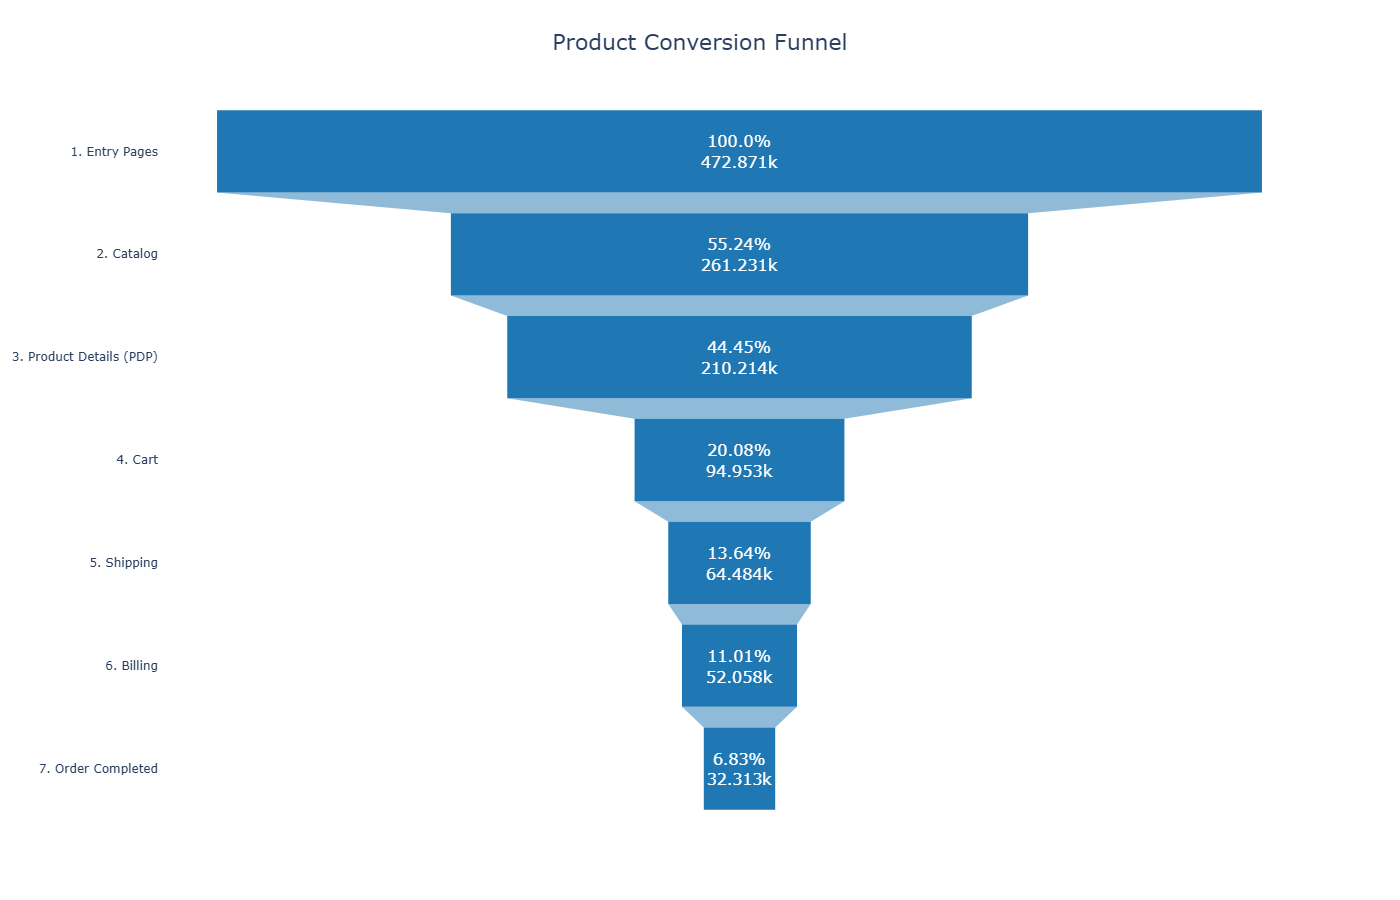

### Executive Insights & Funnel Optimization Strategy

Based on the interactive funnel metrics (Overall Conversion Rate: **6.83%**), we have identified three critical bottlenecks where the business is losing potential revenue:

**1. Top-of-Funnel Friction (Entry ➔ Catalog)**
* **Data:** Only **55.24%** of users proceed from their entry page to the catalog. Nearly 45% of our acquired traffic bounces immediately.
* **Hypothesis:** This high bounce rate suggests a potential mismatch between ad messaging and landing page content, slow page load times, or weak Call-to-Action (CTA) placement on the `/home` and `/lander` pages.
* **Recommendation:** Conduct A/B testing on landing page headlines and images to better align with marketing campaigns.

**2. Billing Conversion Gap (Billing ➔ Order Completed)**
* **Data:** **11.01%** of users reach the billing stage, but only **6.83%** successfully complete the order. This represents a massive ~38% relative drop-off at the very last step where users already have their credit cards out.
* **Hypothesis:** This is a critical revenue leak likely caused by technical payment gateway errors, a lack of trusted payment options (e.g., Apple Pay, PayPal), or unexpected fees appearing at the final step.
* **Recommendation:** Immediate technical audit of the `/billing` page. 

---

## 2. A/B/n Testing: Landing Page Optimization

### Objective & Strategic Pivot
While it is tempting to evaluate landing pages based on micro-conversions (e.g., Click-Through Rate to the `/products` catalog), doing so assumes a strict, linear user journey. Users might bypass the catalog entirely if the landing page features direct "Add to Cart" functionality. 

To account for all possible user flows and focus on the ultimate business impact, our primary target metric for this test is the **Macro-Conversion Rate**. We aim to determine if any custom landing page (`/lander-1` through `/lander-5`) yields a statistically significant increase in final purchases compared to the baseline `/home` page.

### Experiment Setup
* **Target Metric:** Order Conversion Rate $\left(\frac{\text{Total Orders}}{\text{Total Sessions}}\right)$
* **Control Group:** `/home`
* **Test Groups:** `/lander-1` to `/lander-5`

### Statistical Methodology
Since Conversion Rate is a proportion based on binary outcomes (Order vs. No Order), we apply a rigorous two-step statistical approach:
1. **Chi-Square Test:** First, we check for *any* statistically significant variance in conversion rates across all 6 pages combined.
2. **Pairwise Z-Tests for Proportions:** If the global test is significant, we run individual Z-tests to compare each `/lander` against `/home`.
3. **Bonferroni Correction:** To control the False Positive Rate across multiple comparisons, we adjust our significance threshold. For 5 targeted comparisons (each `/lander` vs. `/home`), our adjusted alpha becomes $\alpha = \frac{0.05}{5} = 0.01$. A variant is declared a winner only if its p-value is strictly less than 0.01.

In [18]:
ab_test_query = '''
    WITH session_flags AS (
        SELECT 
            website_session_id,
            MIN(website_pageview_id) as entry_pageview_id,
            MAX(CASE WHEN pageview_url = '/thank-you-for-your-order' THEN 1 ELSE 0 END) as order_completed
        FROM website_pageviews
        GROUP BY website_session_id 
    ),
    landing_pages AS (
        SELECT 
            f.website_session_id,
            p.pageview_url as landing_page,
            f.order_completed
        FROM session_flags f
        JOIN website_pageviews p 
            ON f.entry_pageview_id = p.website_pageview_id
        WHERE p.pageview_url IN ('/home', '/lander-1', '/lander-2', '/lander-3', '/lander-4', '/lander-5')
    )

    SELECT 
        landing_page,
        COUNT(website_session_id) as total_sessions,
        SUM(order_completed) as total_orders,
        ROUND(SUM(order_completed) / COUNT(website_session_id) * 100, 2) as conversion_rate_pct
    FROM landing_pages
    GROUP BY landing_page
    ORDER BY landing_page;
'''

ab_test_df = pd.read_sql(ab_test_query, con=engine)
ab_test_df

,landing_page,total_sessions,total_orders,conversion_rate_pct
0,/home,137576,9711.0,7.06
1,/lander-1,47574,2157.0,4.53
2,/lander-2,131170,10128.0,7.72
3,/lander-3,79000,2679.0,3.39
4,/lander-4,9385,708.0,7.54
5,/lander-5,68166,6930.0,10.17


In [19]:
import scipy.stats as stats

ab_test_df['not_converted'] = ab_test_df['total_sessions'] - ab_test_df['total_orders']

# Build the contingency table [Successes, Failures]
contingency_table = ab_test_df[['total_orders', 'not_converted']].values

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-value: {p_value:.5e}\n") 

alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis (H0).")
    print("The difference in conversion rates across landing pages is STATISTICALLY SIGNIFICANT.")
    print("We can proceed with pairwise Z-tests to identify the best performing variant.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis (H0).")
    print("The difference in conversion rates is due to random noise. No landing page had a significant effect.")

Chi-Square Statistic: 3235.69
P-value: 0.00000e+00

Conclusion: Reject the Null Hypothesis (H0).
The difference in conversion rates across landing pages is STATISTICALLY SIGNIFICANT.
We can proceed with pairwise Z-tests to identify the best performing variant.


In [20]:
control_data = ab_test_df[ab_test_df['landing_page'] == '/home'].iloc[0]
control_orders = control_data['total_orders']
control_sessions = control_data['total_sessions']
control_conv = control_data['conversion_rate_pct']

print(f"/home (Conversion Rate: {control_conv}%)\n")

alpha_corrected = 0.05 / 5

for index, row in ab_test_df.iterrows():
    variant = row['landing_page']
    
    if variant == '/home':
        continue
        
    variant_orders = row['total_orders']
    variant_sessions = row['total_sessions']
    variant_conv = row['conversion_rate_pct']
    
    successes = [variant_orders, control_orders]
    trials = [variant_sessions, control_sessions]
    
    z_stat, p_val = proportions_ztest(count=successes, nobs=trials)
    
    if p_val < alpha_corrected:
        if variant_conv > control_conv:
            status = "Significantly Better"
        else:
            status = "Significantly Worse"
    else:
        status = "No Significant Difference"
        
    print(f"Variant: {variant} (Conversion Rate: {variant_conv}%)")
    print(f"P-value: {p_val:.5e} | Threshold: {alpha_corrected}")
    print(f"Status:  {status}")
    print("-" * 60)

/home (Conversion Rate: 7.06%)

Variant: /lander-1 (Conversion Rate: 4.53%)
P-value: 1.13771e-83 | Threshold: 0.01
Status:  Significantly Worse
------------------------------------------------------------
Variant: /lander-2 (Conversion Rate: 7.72%)
P-value: 5.14031e-11 | Threshold: 0.01
Status:  Significantly Better
------------------------------------------------------------
Variant: /lander-3 (Conversion Rate: 3.39%)
P-value: 3.95621e-274 | Threshold: 0.01
Status:  Significantly Worse
------------------------------------------------------------
Variant: /lander-4 (Conversion Rate: 7.54%)
P-value: 7.63281e-02 | Threshold: 0.01
Status:  No Significant Difference
------------------------------------------------------------
Variant: /lander-5 (Conversion Rate: 10.17%)
P-value: 8.47367e-131 | Threshold: 0.01
Status:  Significantly Better
------------------------------------------------------------


### Business Conclusions & Recommendations

Based on the rigorous A/B testing and pairwise Z-tests with Bonferroni correction ($\alpha = 0.01$), we can draw the following data-driven conclusions:

*  `/lander-5` is the clear champion, yielding a **10.17%** conversion rate compared to the `/home` baseline of 7.06%. The p-value is practically zero, indicating extreme statistical significance.
*  `/lander-2` also significantly outperformed the baseline (7.72%), but falls short of the performance seen in `/lander-5`.
* **The "Illusion" of Success:** `/lander-4` presents a fascinating case. While its nominal conversion rate (7.54%) appears higher than the baseline, the p-value of 0.076 exceeds our strict 0.01 threshold. This result is not statistically significant and is likely due to random variance.
* **The Underperformers:** `/lander-1` (4.53%) and `/lander-3` (3.39%) significantly harmed the conversion rate and should be retired immediately.

**Final Recommendation:**
The marketing and engineering teams should immediately deprecate all experimental landing pages and the baseline `/home` page for paid traffic. **Roll out `/lander-5` to 100% of incoming ad traffic.** This single product change is projected to increase the overall baseline conversion rate by approximately 3 percentage points, driving massive incremental revenue.

---

## 3. Marketing Analytics & Traffic Optimization

### Strategic Objective
Having optimized the product entry point via A/B testing, we now shift our focus to the top of the funnel: **Traffic Acquisition**. We must evaluate the *quality* and *profitability* of our traffic to ensure optimal allocation of the marketing budget.

In this section, we will leverage SQL to extract and analyze UTM parameters, answering three critical business questions:

1. **Campaign Profitability (Revenue per Session):** Which traffic sources and campaigns yield the highest return on ad spend? By calculating the Revenue per Session (RPS), we will identify exactly which channels deserve a budget increase.
2. **Device-Level Bidding Strategy:** How do purchasing behaviors differ between mobile and desktop users? We will analyze conversion rates and revenue by device type to recommend data-driven bid adjustments for Google Ads.
3. **Brand vs. Non-Brand Traffic Dynamics:** What is the behavioral difference between high-intent "warm" users (searching for our specific brand) and generic explorers? 

In [65]:
marketing_sql = '''
    SELECT 
        COALESCE(s.utm_source, 'organic_direct') AS utm_source,
        COALESCE(s.utm_campaign, 'organic_direct') AS utm_campaign,
        COALESCE(s.utm_content, 'organic_direct') AS utm_content,
        s.device_type,
        
        COUNT(s.website_session_id) AS total_sessions,
        SUM(o.price_usd) AS total_revenue
        
    FROM website_sessions s 
    LEFT JOIN orders o 
        ON s.website_session_id = o.website_session_id
    GROUP BY 
        1, 2, 3, 4
'''

marketing_df = pd.read_sql(marketing_sql, con=engine)
marketing_df

,utm_source,utm_campaign,utm_content,device_type,total_sessions,total_revenue
0,gsearch,nonbrand,g_ad_1,mobile,87551,168397.31
1,gsearch,nonbrand,g_ad_1,desktop,195155,956016.90
2,organic_direct,organic_direct,organic_direct,mobile,31752,61247.42
3,organic_direct,organic_direct,organic_direct,desktop,51576,310185.61
4,gsearch,brand,g_ad_2,desktop,19922,126801.76
5,gsearch,brand,g_ad_2,mobile,13407,24928.92
6,bsearch,brand,b_ad_2,desktop,6867,41645.31
7,bsearch,brand,b_ad_2,mobile,1047,1463.71
8,bsearch,nonbrand,b_ad_1,desktop,47395,211434.40
9,bsearch,nonbrand,b_ad_1,mobile,7514,14129.08


In [69]:
# 1. Device Performance
device_df = marketing_df.groupby('device_type')[['total_sessions', 'total_revenue']].sum().reset_index()
device_df['revenue_per_session'] = round(device_df['total_revenue'] / device_df['total_sessions'], 2)
device_df.sort_values('revenue_per_session', ascending=False)

,device_type,total_sessions,total_revenue,revenue_per_session
0,desktop,327027,1665757.84,5.09
1,mobile,145844,272751.91,1.87


In [70]:
# 2. Brand vs Non-Brand (Filtering for Search Traffic)
search_df = marketing_df[marketing_df['utm_source'].isin(['gsearch', 'bsearch'])]
brand_df = search_df.groupby('utm_campaign')[['total_sessions', 'total_revenue']].sum().reset_index()
brand_df['revenue_per_session'] = round(brand_df['total_revenue'] / brand_df['total_sessions'], 2)
brand_df.sort_values('revenue_per_session', ascending=False)

,utm_campaign,total_sessions,total_revenue,revenue_per_session
0,brand,41243,194839.70,4.72
1,nonbrand,337615,1349977.69,4.00


In [71]:
# 3. Overall Source Performance
source_df = marketing_df.groupby('utm_source')[['total_sessions', 'total_revenue']].sum().reset_index()
source_df['revenue_per_session'] = round(source_df['total_revenue'] / source_df['total_sessions'], 2)
source_df.sort_values('revenue_per_session', ascending=False)

,utm_source,total_sessions,total_revenue,revenue_per_session
2,organic_direct,83328,371433.03,4.46
0,bsearch,62823,268672.50,4.28
1,gsearch,316035,1276144.89,4.04
3,socialbook,10685,22259.33,2.08


### Strategic Marketing Insights & Recommendations

Based on the multi-dimensional analysis of our traffic and revenue per session (RPS), we have identified several critical opportunities for budget optimization:

1. **Implement Aggressive Device-Level Bidding:**
   * **Finding:** Desktop users generate a massive **$5.09 RPS**, compared to just **$1.87 RPS** for mobile users. 
   * **Recommendation:** The marketing team should immediately apply a positive bid adjustment for Desktop traffic to capture more of this highly profitable segment, while significantly reducing bids for Mobile traffic until the mobile UX is improved.

2. **Reallocate Search Engine Budget (The Bing Opportunity):**
   * **Finding:** While Google Search (`gsearch`) drives the highest volume, Bing Search (`bsearch`) is actually more efficient, generating **$4.28 RPS** versus Google's $4.04.
   * **Recommendation:** Scale the advertising budget for `bsearch`. Since the traffic is highly qualified, increasing our impression share on Bing will likely yield a higher Return on Ad Spend (ROAS).

3. **Investigate Social Media Performance (Socialbook):**
   * **Finding:** `socialbook` campaigns yield a lower RPS of **$2.08**, which is expected for top-of-funnel social traffic compared to high-intent search traffic.
   * **Analytical Nuance:** A lower RPS does not automatically imply unprofitability, as social media cost-per-click (CPC) is typically much lower than search engine bids.
   * **Next Step:** To calculate exact ROAS (Return on Ad Spend), we need to integrate marketing cost data. If the acquisition cost per session is significantly below $2.08, this channel remains a highly viable source for low-cost volume growth.